## 4-1. 인구현황 데이터 분석

## 1. 지역별 총인구수 top5

In [18]:
import pandas as pd
print(pd.__version__)

2.2.2


In [19]:
data = pd.read_csv('data/인구현황.csv')


gy_df = data.loc[data['행정기관'] != '전국', ['행정기관', '총인구수']]
gy_df = gy_df.sort_values(by='총인구수', ascending=False).head(5)
gy_df


,행정기관,총인구수
9,경기도,13694685
1,서울특별시,9331828
2,부산광역시,3266598
16,경상남도,3228380
4,인천광역시,3021010


## 1-1. 지역별 총인구수 plot

In [20]:
%matplotlib inline

In [21]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

In [22]:
[ (font.name, font.fname) for font in fm.fontManager.ttflist if 'Mal' in font.name ]


[('Malgun Gothic', 'C:\\Windows\\Fonts\\malgunbd.ttf'),
 ('Malgun Gothic', 'C:\\Windows\\Fonts\\malgun.ttf'),
 ('Malgun Gothic', 'C:\\Windows\\Fonts\\malgunsl.ttf')]

In [23]:
font_path = 'C:\\Windows\\Fonts\\malgun.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()
matplotlib.rc('font', family=font_name)

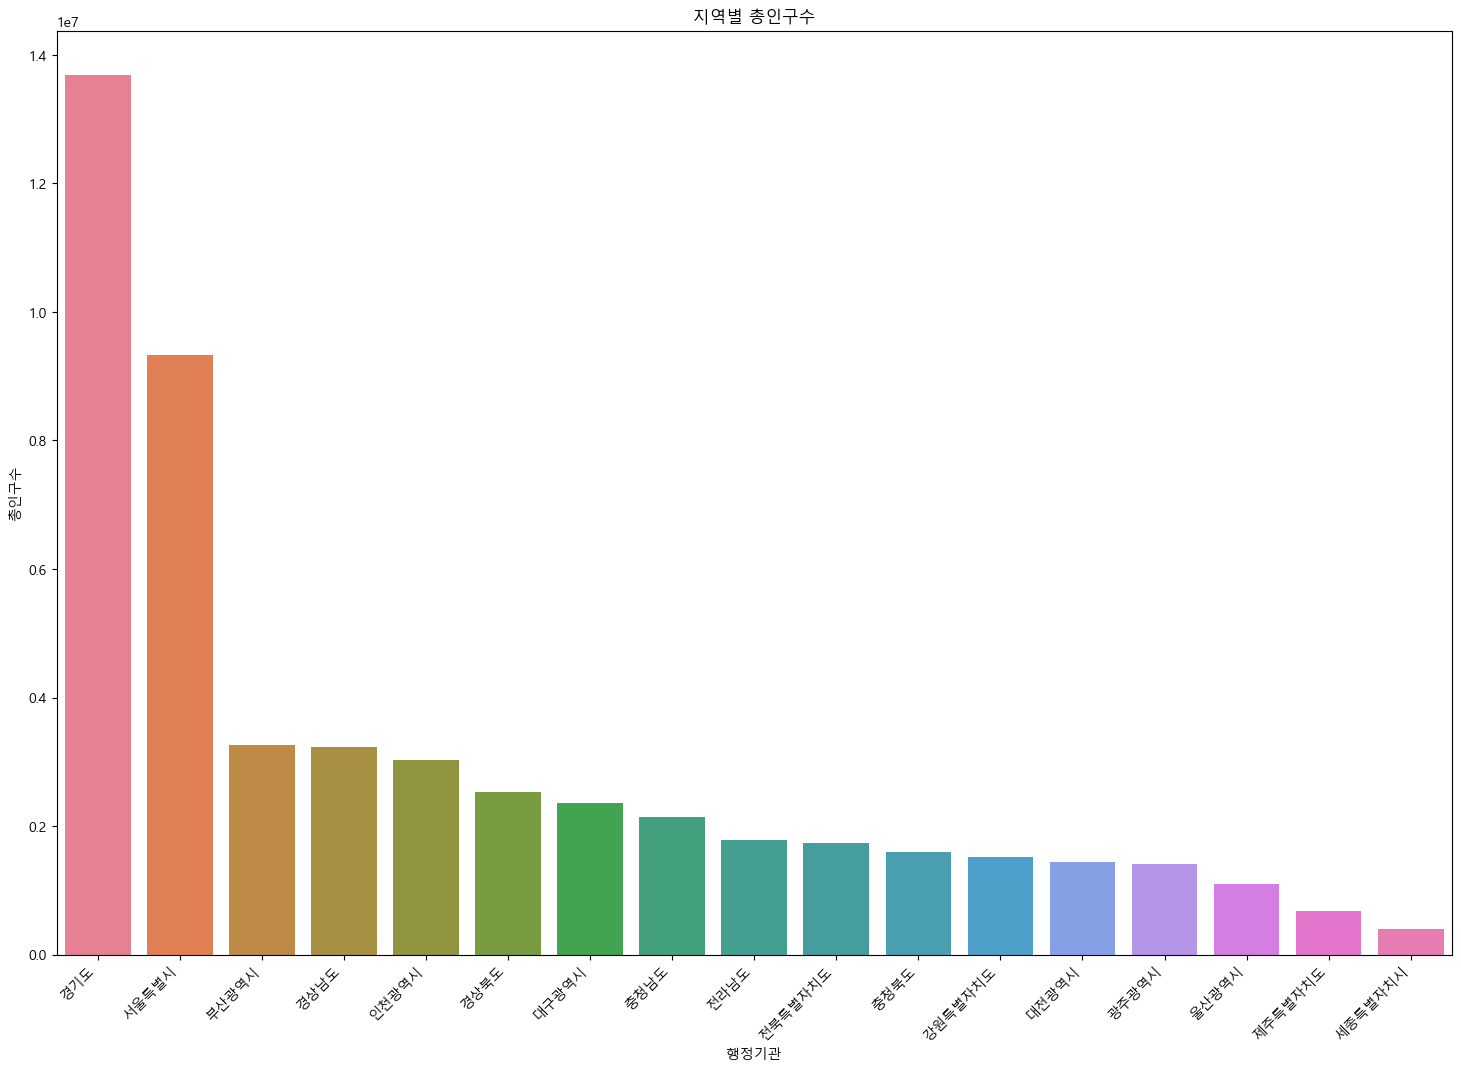

In [24]:
gy_df_all = data.loc[data['행정기관'] != '전국', ['행정기관', '총인구수']]
gy_df_all = gy_df_all.sort_values(by='총인구수', ascending=False)

figure, axes = plt.subplots(nrows=1, ncols=1)
figure.set_size_inches(18, 12)

pop_plot = sns.barplot(data=gy_df_all, x='행정기관', y='총인구수', ax=axes, hue='행정기관')
pop_plot.set_title('지역별 총인구수')
pop_plot.set_xticks(pop_plot.get_xticks())
pop_plot.set_xticklabels(pop_plot.get_xticklabels(), rotation=45, ha='right')
plt.show()

### 2. 세대당 인구수 높은 지역 TOP5

In [25]:
data = pd.read_csv('data/인구현황.csv')

per_house_df = data.loc[data['행정기관'] != '전국', ['행정기관', '세대당 인구']]
per_house_df = per_house_df.sort_values(by='세대당 인구', ascending=False).head(5).copy()
per_house_df


,행정기관,세대당 인구
8,세종특별자치시,2.39
9,경기도,2.26
7,울산광역시,2.22
4,인천광역시,2.20
3,대구광역시,2.14


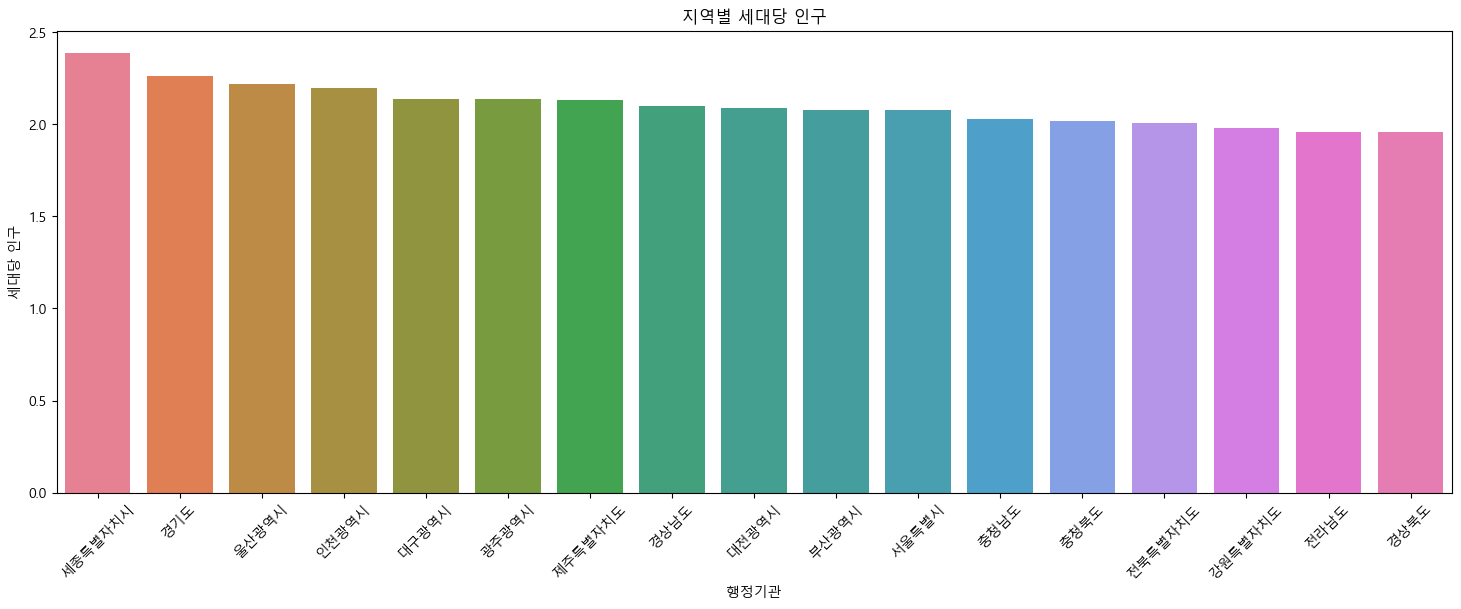

In [26]:
figure,axes = plt.subplots(nrows=1,ncols=1)
figure.set_size_inches(18,6)

per_house_all = data.loc[data['행정기관'] != '전국', ['행정기관', '세대당 인구']]
per_house_all = per_house_all.sort_values(by='세대당 인구', ascending=False)

plot = sns.barplot(data=per_house_all, x ='행정기관', y='세대당 인구', ax=axes, hue='행정기관')
plot.set_title('지역별 세대당 인구')
plot.tick_params(axis='x', rotation=45)

plt.show()

## 3. 남녀 비율 분석

In [27]:
girl_boy_df = data.loc[data['행정기관']!= '전국',['행정기관','남여 비율']]
girl_boy_df = girl_boy_df.sort_values(by='남여 비율',ascending=False).reset_index(drop=True)
girl_boy_df

,행정기관,남여 비율
0,울산광역시,1.06
1,충청남도,1.05
2,충청북도,1.04
3,경상남도,1.02
4,경상북도,1.02
5,전라남도,1.02
6,경기도,1.01
7,강원특별자치도,1.01
8,제주특별자치도,1.00
9,인천광역시,1.00


## 3-1. 남여 비율 분석 plot

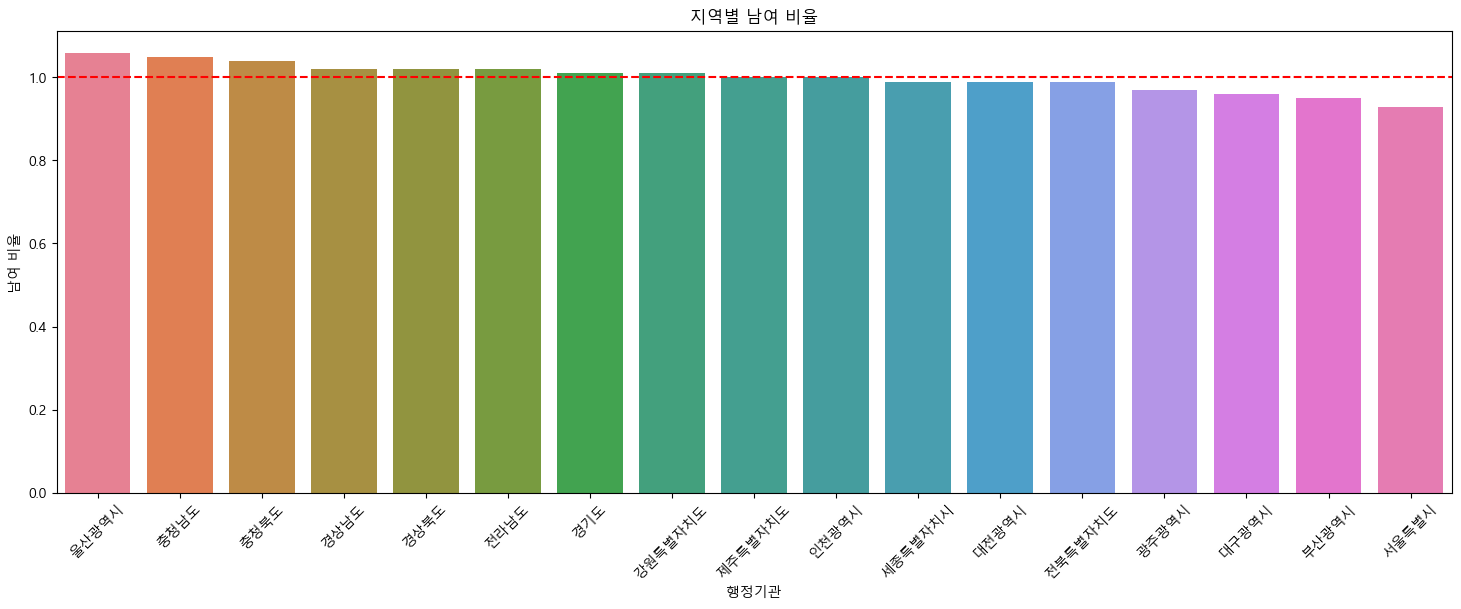

In [28]:

figure,axes3 = plt.subplots(nrows=1,ncols=1)
figure.set_size_inches(18,6)

plot = sns.barplot(data=girl_boy_df, x ='행정기관', y='남여 비율', ax=axes3, hue='행정기관')
plot.axhline(y=1.0, color='red', linestyle='--', label='남녀 1:1 비율')
plot.set_title('지역별 남여 비율')
plot.tick_params(axis='x', rotation=45)

plt.show()


## 4. 남자초과 / 여자초과 분석

In [29]:
girl_boy_over_df = data.loc[data['행정기관'] != '전국', ['행정기관', '남여 비율']]
girl_boy_over_df = girl_boy_over_df.sort_values(by='남여 비율', ascending=False).reset_index(drop=True)

girl_boy_over_df['남초여초'] = girl_boy_over_df['남여 비율'].apply(
    lambda x: '여초' if x < 1 else ('남초' if x > 1 else '동일')
)
girl_boy_over_df

,행정기관,남여 비율,남초여초
0,울산광역시,1.06,남초
1,충청남도,1.05,남초
2,충청북도,1.04,남초
3,경상남도,1.02,남초
4,경상북도,1.02,남초
5,전라남도,1.02,남초
6,경기도,1.01,남초
7,강원특별자치도,1.01,남초
8,제주특별자치도,1.00,동일
9,인천광역시,1.00,동일


## 5. 세대당 인구 평균보다 높은 지역

In [30]:
national_avg = data.loc[data['행정기관'] == '전국','세대당 인구'].values[0]

above_avg_df = data.loc [(data['행정기관'] != '전국') & (data['세대당 인구']> national_avg), ['행정기관','세대당 인구']]

above_avg_df = above_avg_df.sort_values(by='세대당 인구', ascending=False).reset_index(drop=True)
above_avg_df

,행정기관,세대당 인구
0,세종특별자치시,2.39
1,경기도,2.26
2,울산광역시,2.22
3,인천광역시,2.20
4,대구광역시,2.14
5,광주광역시,2.14
6,제주특별자치도,2.13


## 5-1. 남초 vs 여초 개수 plot, 지역별 세대수 Plot

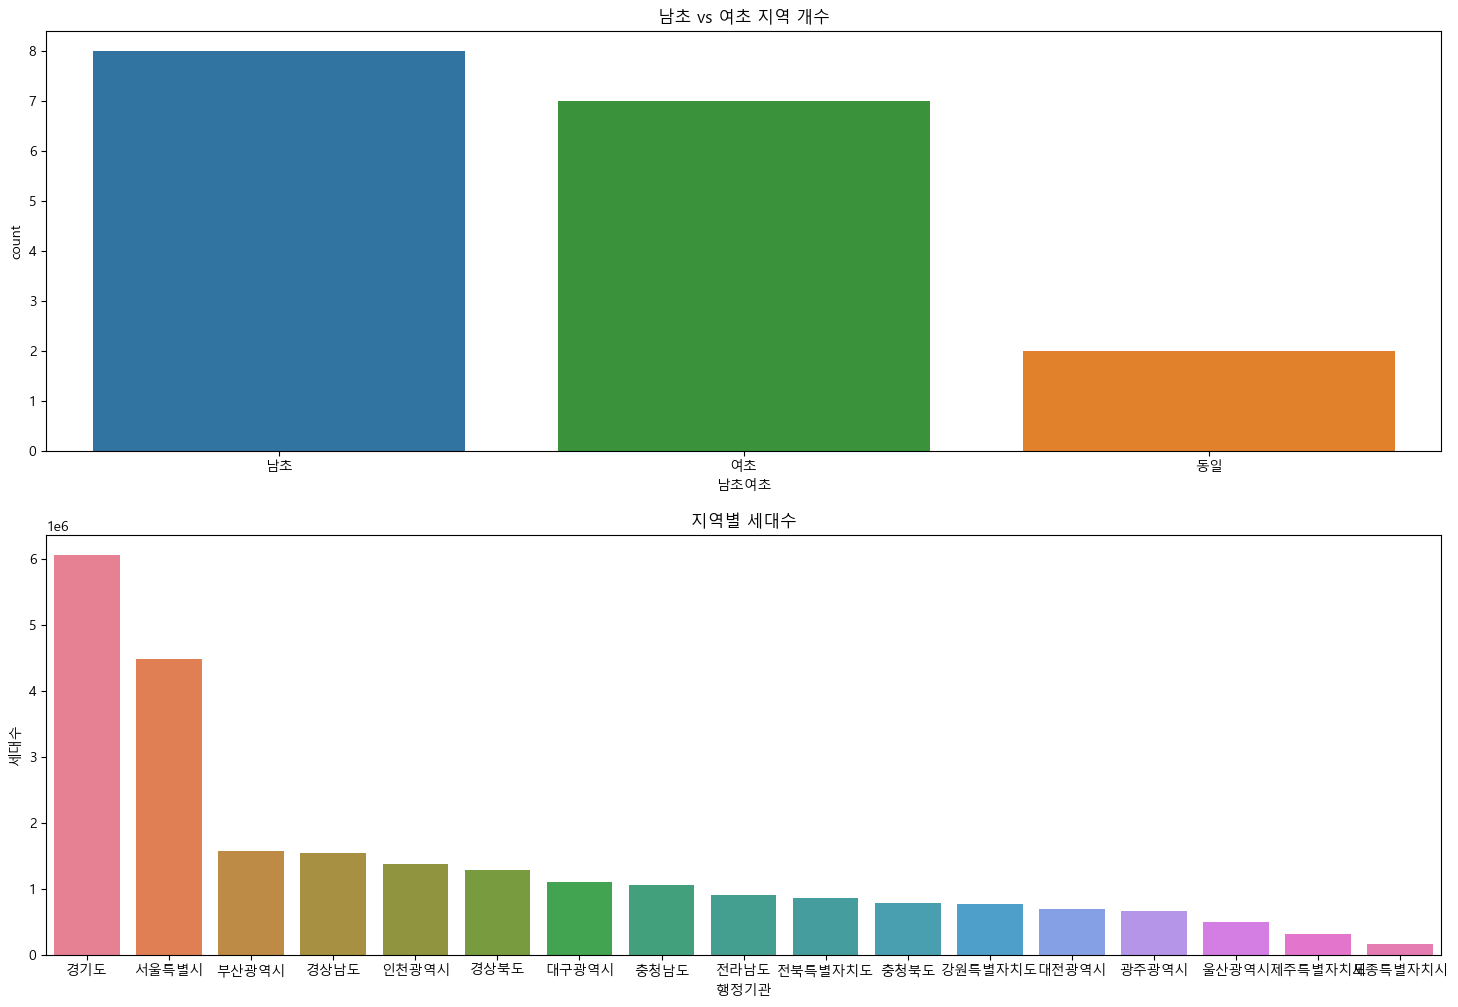

In [31]:
house_count_df = data.loc[data['행정기관'] != '전국', ['행정기관', '세대수']]
house_count_df = house_count_df.sort_values(by='세대수', ascending=False)

figure, (axes4, axes5) = plt.subplots(nrows=2, ncols=1)
figure.set_size_inches(18, 12)

sns.countplot(data=girl_boy_over_df, x='남초여초', ax=axes4,
              order=girl_boy_over_df['남초여초'].value_counts().index,
              hue='남초여초')
axes4.set_title('남초 vs 여초 지역 개수')

sns.barplot(data=house_count_df, x='행정기관', y='세대수', ax=axes5,
            order=house_count_df['행정기관'],
            hue='행정기관')
axes5.set_title('지역별 세대수')

plt.show()